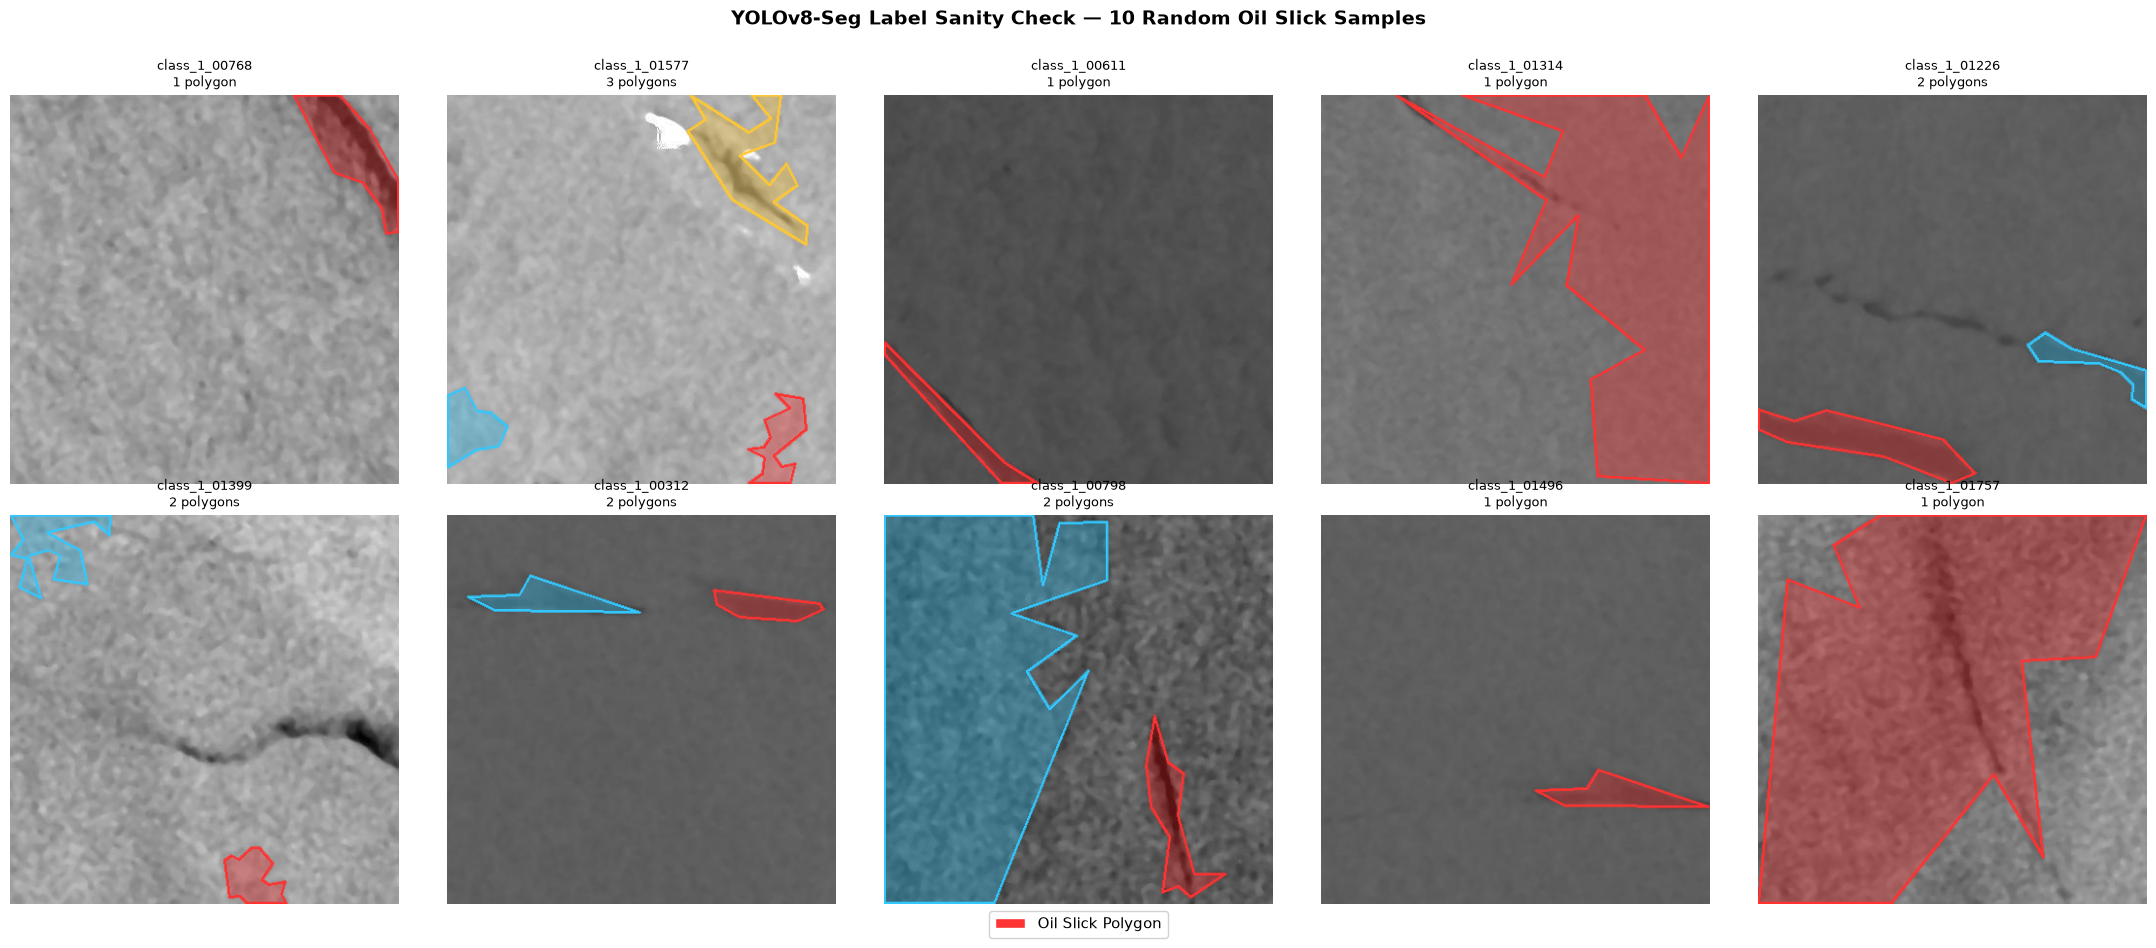


✅  Saved to outputs/label_sanity_check.png


In [2]:
"""
Visualize 10 random oil slick images with their YOLO-seg polygon overlays.
Run this in the ai-model/notebooks/ directory.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
from pathlib import Path

# ─── Paths ────────────────────────────────────────────────────────────────────
IMAGES_DIR = Path("../data/images/train")
LABELS_DIR = Path("../data/labels/train")

# ─── Pick 10 random labelled images ──────────────────────────────────────────
label_files = sorted(LABELS_DIR.glob("class_1_*.txt"))
sample_labels = random.sample(label_files, min(10, len(label_files)))

# ─── Draw grid ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("YOLOv8-Seg Label Sanity Check — 10 Random Oil Slick Samples",
             fontsize=14, fontweight="bold", y=1.01)

COLORS = [
    (255,  50,  50),   # red
    ( 50, 200, 255),   # cyan
    (255, 200,  50),   # yellow
    ( 50, 255, 100),   # green
    (200,  50, 255),   # purple
]

for ax, lbl_path in zip(axes.flatten(), sample_labels):
    img_path = IMAGES_DIR / lbl_path.with_suffix(".jpg").name

    if not img_path.exists():
        ax.set_visible(False)
        continue

    # Load image as RGB
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Overlay each polygon in the label file
    lines = lbl_path.read_text().strip().splitlines()
    overlay = img.copy()

    for idx, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        coords = list(map(float, parts[1:]))
        pts = np.array(
            [[int(coords[i] * w), int(coords[i+1] * h)]
             for i in range(0, len(coords), 2)],
            dtype=np.int32
        )
        color = COLORS[idx % len(COLORS)]
        # Filled semi-transparent polygon
        cv2.fillPoly(overlay, [pts], color)
        # Sharp outline
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)

    # Blend overlay at 35% opacity
    img = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)

    n_polys = len(lines)
    ax.imshow(img)
    ax.set_title(f"{lbl_path.stem}\n{n_polys} polygon{'s' if n_polys>1 else ''}", fontsize=9)
    ax.axis("off")

# Legend
patch = mpatches.Patch(facecolor=(1, 0.2, 0.2), edgecolor="white",
                        label="Oil Slick Polygon")
fig.legend(handles=[patch], loc="lower center", fontsize=11, ncol=1,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("../outputs/label_sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅  Saved to outputs/label_sanity_check.png")

